In [1]:
!pip install selenium
!pip install undetected-chromedriver
!pip install webdriver_manager

import csv
import requests
from bs4 import BeautifulSoup as bs
import random
import time
import pandas as pd
import numpy as np
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys

from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

import undetected_chromedriver as uc
import time

In [2]:
browser = uc.Chrome(version_main=145)

In [3]:
url = "https://www.mercadolibre.com.mx/ofertas/novedades-de-temporada"

In [4]:
browser.get(url)

In [5]:
browser.implicitly_wait(10)

In [5]:
cookies_button = WebDriverWait(browser, 10).until(
    EC.element_to_be_clickable((By.XPATH, '/html/body/div[1]/div[1]/div/div[2]/button[1]'))
)
    
# Click the button once it's available
cookies_button.click()

In [7]:
browser.implicitly_wait(10)

In [8]:
#Este es para el codigo postal

cp_button = WebDriverWait(browser, 10).until(
    EC.element_to_be_clickable((By.XPATH, '/html/body/div[5]/div/div/div[2]/div/div/div[2]/button[2]'))
)

cp_button.click()

In [6]:
html = browser.page_source

<html lang="es-MX"><head><link href="https://www.google-analytics.com" rel="preconnect"/><link href="https://www.google.com" rel="preconnect"/><link href="https://data.mercadolibre.com" rel="preconnect"/><link href="https://http2.mlstatic.com" rel="preconnect"/><link href="https://stats.g.doubleclick.net" rel="preconnect"/><link href="https://www.google.com.mx" rel="preconnect"/><script async="" src="https://connect.facebook.net/signals/config/351742151669639?v=2.9.274&amp;r=stable&amp;domain=www.mercadolibre.com.mx&amp;hme=8830461b0a3fda5230edea4335366eb6d682f53a525e54f7adf6ff7b70c96c39&amp;ex_m=100%2C193%2C142%2C22%2C69%2C70%2C135%2C65%2C64%2C11%2C150%2C86%2C16%2C129%2C122%2C72%2C75%2C128%2C147%2C152%2C8%2C4%2C5%2C7%2C6%2C3%2C87%2C97%2C153%2C158%2C207%2C59%2C174%2C175%2C52%2C251%2C30%2C71%2C219%2C218%2C217%2C23%2C32%2C99%2C58%2C10%2C60%2C93%2C94%2C95%2C101%2C125%2C31%2C29%2C127%2C124%2C123%2C143%2C73%2C146%2C144%2C145%2C47%2C57%2C118%2C15%2C149%2C42%2C239%2C240%2C238%2C26%2C27%2C28%2
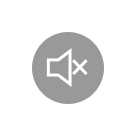
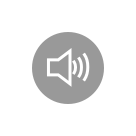
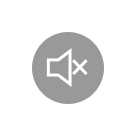
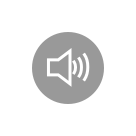

In [7]:
soup = bs(html, 'lxml')
soup

In [8]:
soup.find('h3', {'class':'poly-component__title-wrapper'}).text

'U Bárbara Pijama Quirúrgica Corte Recto Con Bolsas Uniforme'

In [9]:
soup.find('div', {'class':'andes-card poly-card poly-card--grid-card poly-card--xlarge andes-card--flat andes-card--padding-0 andes-card--animated'})

<div class="andes-card poly-card poly-card--grid-card poly-card--xlarge andes-card--flat andes-card--padding-0 andes-card--animated" id=":R1gqt79h:"><div class="poly-card__portada"><span class="poly-component__image-overlay"></span><img alt="U Bárbara Pijama Quirúrgica Corte Recto Con Bolsas Uniforme" aria-hidden="true" class="poly-component__picture" decoding="async" height="150" src="https://http2.mlstatic.com/D_Q_NP_2X_737869-MLM91219734015_082025-AB-u-barbara-pijama-quirurgica-corte-recto-con-bolsas-uniforme.webp" title="U Bárbara Pijama Quirúrgica Corte Recto Con Bolsas Uniforme" width="150"/></div><div class="poly-card__content"><span class="poly-component__highlight" style="color:#FFFFFF;background-color:#3483FA">OFERTA DEL DÍA</span><h3 class="poly-component__title-wrapper"><a class="poly-component__title" href="https://articulo.mercadolibre.com.mx/MLM-2077544317-u-barbara-pijama-quirurgica-corte-recto-con-bolsas-uniforme-_JM?searchVariation=180674601528#polycard_client=splinte

In [22]:
driver = webdriver.Chrome()

def extraer_y_guardar_csv(url, nombre_archivo="novedades_MercLib.csv"):
    driver.get(url)
    
    productos = driver.find_elements(By.CLASS_NAME, "poly-card")
    
    with open(nombre_archivo, mode='w', newline='', encoding='utf-8') as archivo_csv:
        campos = ['Titulo', 'Precio', 'Calificacion', 'Ventas/Info']
        writer = csv.DictWriter(archivo_csv, fieldnames=campos)
        writer.writeheader()

        print(f"Extrayendo {len(productos)} productos...")

        for item in productos:
            try:
                titulo = item.find_element(By.CLASS_NAME, "poly-component__title-wrapper").text

                precio_entero = item.find_element(By.CLASS_NAME, "andes-money-amount__fraction").text
                try:
                    centavos = item.find_element(By.CLASS_NAME, "andes-money-amount__cents").text
                    precio_final = f"{precio_entero}.{centavos}"
                except:
                    precio_final = precio_entero

                try:
                    calificacion = item.find_element(By.CLASS_NAME, "ui-pdp-header__product-classification").text
                except:
                    calificacion = "N/A"

                try:
                    ventas = item.find_element(By.CLASS_NAME, "ui-pdp-header__subtitle").text
                    ventas = ventas.replace("Nuevo  |  ", "").strip()
                except:
                    ventas = "0 vendidos"

                writer.writerow({
                    'Titulo': titulo,
                    'Precio': precio_final,
                    'Calificacion': calificacion,
                    'Ventas/Info': ventas
                })

            except Exception:
                continue

    print(f"¡Hecho! Archivo guardado como: {nombre_archivo}")

url_objetivo = "https://www.mercadolibre.com.mx/ofertas/novedades-de-temporada" 
extraer_y_guardar_csv(url_objetivo)

driver.quit()

Extrayendo 100 productos...
¡Hecho! Archivo guardado como: novedades_MercLib.csv
